# Detección de Anorexia con Natural Lenguage Inference en Redes Sociales
La detección automática de trastornos de la alimentación (TA) en plataformas de redes sociales constituye el enfoque central de esta propuesta. Mediante el análisis de diferentes investigaciones especializadas, se identifican tres arquitecturas representativas: la Red de Atención Jerárquica para la Detección de la Depresión Multiaspecto (MDHAN), aplicada a datos de Twitter; el modelo de aprendizaje por transferencia basado en BETO para la detección de la anorexia en español; y la Unidad Multimodal con Compuerta Multicanal (GMU) para la configuración de análisis holísticos. 

En la evaluación técnica destaca a MDHAN como la arquitectura con la mayor precisión reportada (99,86 %), lograda mediante la optimización híbrida de enjambre de partículas y lobo gris (PWO) para la selección de características. Se documenta la evolución metodológica, desde los modelos clásicos basados en bolsas de palabras hasta las soluciones actuales basadas en Transformers, con énfasis en el uso de la Inferencia de Lenguaje Natural (NLI) para capturar biomarcadores lingüísticos y semánticos implícitos que apoyen la toma de decisiones clínicas en el ámbito específico de los trastornos de la conducta alimentaria (TCA). Se presenta un análisis que compara la precisión, la complejidad computacional y la capacidad de generalización semántica entre distintas aproximaciones de clasificación, junto con un conjunto de objetivos experimentales propuestos para evaluar el rendimiento de modelos lineales, no lineales y probabilísticos alimentados por representaciones vectoriales densas.

## Descripción del modelo de solución propuesto
El análisis del estado del arte en la detección de trastornos mentales revela una trayectoria que comenzó con el uso intensivo de Bag of Words (BoW) y SVM, modelos eficientes pero limitados por su rigidez léxica. Para superar estas barreras, el diseño propuesto implementa un enfoque basado en Inferencia de Lenguaje Natural (NLI) y aprendizaje de representaciones (Representation Learning) mediante el modelo Transformer DeBERTa-v3 (como DeBERTa-v3-large-xnli).

Esta arquitectura reformula el problema de clasificación textual, eliminando la dependencia de conteos de palabras estadísticas o n-gramas rígidos. En su lugar, el proceso opera de la siguiente manera:

- **Formulación de Premisas e Hipótesis:** Cada publicación extraída de redes sociales actúa como una Premisa. De forma paralela, se diseñan hipótesis clínicas específicas basadas en criterios médicos (por ejemplo: "Este texto expresa conductas de ayuno, restricción alimentaria o insatisfacción corporal").

- **Extracción de Embeddings de Contexto Profundo:** El par (Tweet, Hipótesis) se procesa a través del codificador de DeBERTa, aprovechando su mecanismo de atención desenredada (disentangled attention) y su preentrenamiento masivo. El modelo genera vectores densos (embeddings) de alta dimensionalidad que encapsulan relaciones semánticas abstractas y la interacción lógica profunda entre el texto del usuario y los constructos diagnósticos.

- **Alineación Semántica:** En lugar de mapear palabras clave aisladas, la capa NLI calcula las probabilidades de relación lógica: Entailment (Implicación/Verdad), Contradiction (Contradicción/Falso) y Neutral. La probabilidad de Entailment se extrae como la puntuación base de riesgo semántico, blindando al sistema ante el uso de sinónimos neológicos(palabras nuevas del lenguaje), metáforas o variaciones lingüísticas que los enfoques léxicos (como TF-IDF) suelen ignorar por falta de coincidencia de raíces exactas.

Para el alcance actual del proyecto, estas representaciones densas y ricas en contexto de DeBERTa se inyectarán como vectores de características de entrada para alimentar y evaluar tres paradigmas de clasificación distintos, permitiendo determinar la capacidad de abstracción de cada algoritmo downstream ante datos altamente no lineales.

## Objetivo de la solución

El objetivo central de esta fase es evaluar experimentalmente la capacidad de discriminación, el rendimiento y el accuracy de tres arquitecturas algorítmicas diferentes cuando son alimentadas con los embeddings semánticos y probabilísticos derivados de DeBERTa-NLI. Colocaremos cara a cara tres metodologías para determinar cuál se desempeña mejor ante la detección de variables de riesgo:

- **Naïve Bayes (NB):** Representa el enfoque probabilístico. Evaluará el rendimiento asumiendo una independencia condicional entre las dimensiones de los embeddings de NLI, sirviendo como una línea base estadística de alta velocidad de cómputo.

- **Regresión Logística (LR):** Como un modelo lineal clásico de clasificación. Medirá la separabilidad lineal de las representaciones vectoriales generadas por el Transformer y su capacidad de respuesta para ajustar una frontera de decisión óptima en espacios de alta dimensionalidad.

- **Random Forest (RF):** Como modelo no lineal basado en ensambles de árboles de decisión. Se plantea la hipótesis de que, debido a su habilidad inherente para capturar interacciones complejas, jerárquicas y no lineales entre las dimensiones del embedding de DeBERTa, RF presentará un rendimiento y una métrica de accuracy superiores frente a los modelos lineal y probabilístico.

Para validar de forma rigurosa estas hipótesis y comprender a fondo la estructura de los datos lingüísticos codificados antes del entrenamiento de los clasificadores, se utilizará la librería ydata-profiling. Esta herramienta de Python automatizará el Análisis Exploratorio de Datos (EDA), generando reportes detallados que nos permitirán identificar de manera inmediata sesgos de distribución, correlaciones multivariables en los embeddings y la consistencia de los biomarcadores clínicos vectorizados con una sola línea de código.

El resultado final de este experimento determinará de forma cuantitativa el "Mérito Relativo" de la arquitectura vanguardista basada en Transformers frente a la clasificación tradicional, estableciendo con métricas claras (Accuracy, Recall y $F_1\text{-score}$) qué clasificador downstream es el óptimo para su despliegue operativo en entornos de monitoreo clínico de TCA.

## Procesamiento del Dataset y Limpieza de Ruido
Los datos extraídos de redes sociales presentan ruido inherente, desde problemas de codificación (Mojibake) hasta terminología no estandarizada, lo que requiere un preprocesamiento cuidadoso para evitar sesgos en la interpretación semántica. Para estandarizar el corpus, se implementó un pipeline secuencial unificado:

1. **Restauración de Codificación:** Se aplicó la librería ftfy para corregir de manera prioritaria caracteres corruptos o mal codificados, garantizando la recuperación de tildes y eñes fundamentales en la semántica del español.

2. **Limpieza Estructural y Segmentación:** Mediante Expresiones Regulares (REGEX), se eliminaron URLs y menciones que carecen de valor clínico. Posteriormente, se aislaron hashtags compuestos (ej. "#hastaloshuesos") y se segmentaron semánticamente, a la par que se normalizó la jerga de internet (slang) hacia un español neutro. Esto previene que el modelo trate variaciones ortográficas de un mismo concepto como entidades desconectadas.

3. **Lematización Contextual:** Con la ayuda del modelo de spaCy, se redujeron las palabras a su raíz léxica (lemas). A diferencia de enfoques clásicos, se tomó la decisión clínica de no eliminar las "stopwords" (artículos, pronombres y conectores). La literatura médica reciente (como los estudios presentados en ACL Anthology) demuestra que la disminución en el uso de pronombres inclusivos ("nosotros") y conectores causales ("porque") actúan como biomarcadores de aislamiento social e indefensión aprendida. Eliminar estas palabras funcionales significaría la pérdida de señales predictivas críticas para la detección de perfiles de riesgo.

In [3]:
import pandas as pd
import ftfy
import re
import spacy
from wordsegment import load, segment

# Inicialización de Modelos y Diccionarios ---
load() # Cargar wordsegment
nlp = spacy.load("es_core_news_sm")

dict_slang = {
    "ntp": "no te preocupes", "pq": "porque", "x q": "porque", 
    "tkm": "te quiero mucho", "d": "de", "q": "que", "toy": "estoy", 
    "chi": "si", "x": "por", "k": "que", "salu2": "saludos", 
    "bno": "bueno", "ño": "no", "onde": "donde", "tmb": "también", 
    "akiora": "a que hora", "aquiora": "a que hora", "shi": "si", 
    "xq": "porque", "xk": "porque"
}

# Nombres de Archivos
ARCHIVO_ENTRENAMIENTO = 'data_train.xlsx'
ARCHIVO_TEST          = 'data_test.csv'

def limpiar_pipeline_completo(texto):
    """
    Ejecuta todo el flujo de limpieza: rescate de caracteres, limpieza regex,
    normalización de slangs/hashtags y lematización.
    """
    if pd.isna(texto) or not isinstance(texto, str):
        return ""
    
    # 1. Rescate ftfy y Limpieza Básica (Regex)
    texto = ftfy.fix_text(texto)
    texto = re.sub(r'https?://\S+|www\.\S+', '', texto) # Quitar URLs
    texto = re.sub(r'@\w+', '', texto)                  # Quitar menciones
    texto = re.sub(r'[^\w\s.,!?¡¿#]', '', texto)        # Mantener puntuación básica y '#' para procesar después
    texto = texto.replace('\n', ' ').replace('\r', '')
    texto = re.sub(r'\s+', ' ', texto).strip().lower()  # Espacios extra y minúsculas
    
    # 2. Segmentación de Hashtags y Normalización de Slang
    palabras = texto.split()
    texto_procesado = []
    
    for p in palabras:
        p_limpia = p.replace('#', '')
        
        if p_limpia in dict_slang:
            texto_procesado.append(dict_slang[p_limpia])
        elif p.startswith('#') and len(p_limpia) > 5:
            seg = segment(p_limpia)
            if len(seg) < 4:
                texto_procesado.extend(seg)
            else:
                texto_procesado.append(p_limpia)
        else:
            texto_procesado.append(p_limpia) # Se inserta la palabra sin el '#'
            
    texto_unido = " ".join(texto_procesado)
    
    # 3. Lematización contextual con spaCy
    doc = nlp(texto_unido)
    lemas = [token.lemma_ for token in doc]
    
    return " ".join(lemas)


# Preparación de Variables para Entrenamiento
print("Cargando y procesando datasets (Train y Test)...")

# Carga de datos
df_train = pd.read_excel(ARCHIVO_ENTRENAMIENTO)
df_test = pd.read_csv(ARCHIVO_TEST, encoding='latin1')

# Aplicar el pipeline unificado
print("Aplicando pipeline de limpieza al set de Entrenamiento...")
df_train['tweet_procesado'] = df_train['tweet_text'].apply(limpiar_pipeline_completo)

print("Aplicando pipeline de limpieza al set de Prueba...")
df_test['tweet_procesado'] = df_test['tweet_text'].apply(limpiar_pipeline_completo)

# Guardado opcional
#df_train[['class', 'tweet_procesado']].to_csv('data_train_reparado.csv', index=False, encoding='utf-8')
#df_test[['class', 'tweet_procesado']].to_csv('data_test_reparado.csv', index=False, encoding='utf-8')

print("\n¡Procesamiento finalizado con éxito!")
print("\n##### Muestra Train #####")
print(df_train[['tweet_text', 'tweet_procesado']].head(2))
print("\n##### Muestra Test #####")
print(df_test[['tweet_text', 'tweet_procesado']].head(2))

Cargando y procesando datasets (Train y Test)...
Aplicando pipeline de limpieza al set de Entrenamiento...
Aplicando pipeline de limpieza al set de Prueba...

¡Procesamiento finalizado con éxito!

##### Muestra Train #####
                                          tweet_text  \
0  Cheesecake saludable sin azÃºcar y sin lactosa...   
1           ser como ellas â™¡â™¡\n  #HastaLosHuesos   

                                     tweet_procesado  
0  cheesecakir saludable sin azúcar y sin lactosa...  
1                          ser como él hastaloshueso  

##### Muestra Test #####
                                          tweet_text  \
0  A ver cuando se empiezan con las de anorexia y...   
1  ÃÂ¡7 dÃÂ­as, 7 razones para entrenar!\n-\nLl...   

                                     tweet_procesado  
0  a ver cuando él empezar con el de anorexia y b...  
1  ¡ 7 día , 7 razón para entrenar ! llegar al do...  


## Extracción de Características Mediante Alineación Lógica-Semántica (NLI)

En las arquitecturas tradicionales de Machine Learning, la matriz de variables $X$ se construye contando la frecuencia de aparición de palabras (como en TF-IDF). En este nuevo enfoque de vanguardia, el paso a seguir consiste en **mecanizar un estándar médico internacional dentro de un Transformer**.

Para dotar al proyecto de un sustento científico, las variables de nuestra matriz $X$ se definieron mediante pares de hipótesis lógicas en un entorno de **Inferencia de Lenguaje Natural (NLI)**.

### El Rol de NotebookLM en la Ingeniería de Prompts Clínicos

Es fundamental destacar que el banco de hipótesis utilizado en este pipeline no fue diseñado de forma empírica o arbitraria. En su lugar, se empleó **NotebookLM** como una herramienta avanzada de curación de contenido y de ingeniería de prompts. A través de este entorno, se alimentaron fuentes y artículos indexados de alta confianza científica que describen de forma rigurosa tres marcos internacionales:

1. **Criterios Diagnósticos del DSM-5 (y CIE-11):** Mapeo directo de los criterios clínicos esenciales para la Anorexia Nerviosa: *Criterio A* (Restricción de la ingesta), *Criterio B* (Miedo intenso a ganar peso) y *Criterio C* (Distorsión de la imagen corporal).
2. **Dimensiones de Conducta RDoC (Research Domain Criteria del NIMH):** Incorporación de dimensiones psicológicas transversales y continuas, tales como los *Sistemas de Valencia Negativa* (culpa y autorreproche postsindromático) y *Sistemas de Regulación Cognitiva* (control obsesivo-rígido de rutinas).
3. **Biomarcadores Lingüísticos de Comunidades Web (Ciberpsicología):** Detección de la jerga de riesgo e idealización de los trastornos característica de entornos *Pro-Ana* y *Pro-Mia*.

NotebookLM extrajo la esencia de estas fuentes médicas y sintetizó el conocimiento en un conjunto de **frases asertivas, claras y descriptivas** (las cuales se detallan en el cuaderno de código adjunto a continuación). Este proceso garantiza que el modelo Transformer entienda el contexto cotidiano de redes sociales sin tecnicismos excesivos, pero manteniendo un anclaje clínico estricto.

Notebook: https://notebooklm.google.com/notebook/171b72dd-f754-4580-bd0c-f1b77f830ea0

### La Lógica de Contradicción y el Blindaje del Modelo

Para replicar el éxito de los sistemas de moderación por alineación de incrustaciones, el modelo necesita un **contraste de seguridad**. Por cada hipótesis de riesgo clínica formulada, se introduce una **hipótesis de control o neutralidad** (vía de escape semántica).

Al pasar el texto preprocesado (Premisa) y este banco de hipótesis sintetizado por NotebookLM por el codificador de **DeBERTa-v3** (específicamente entrenado en tareas XNLI), el modelo calcula la probabilidad de implicación lógica (*Entailment*). Si un tweet se alinea con una hipótesis de riesgo, su puntuación matemática en esa dimensión se eleva; si se alinea con una frase cotidiana o neutra, la puntuación disminuye.

El resultado de este paso será la transformación de texto crudo en matrices densas de probabilidades multidimensionales ($X_{train}$, $X_{val}$, $X_{test}$), listas para ser inyectadas en los clasificadores downstream (**Naïve Bayes, Regresión Logística y Random Forest**).

## Implementación del Pipeline Completo de División y Codificación NLI

El siguiente script en Python realiza la partición del dataset de entrenamiento (80% entrenamiento, 20% validación) para conservar la proporción del desbalance de clases. Posteriormente, utiliza **DeBERTa-v3** para mapear el banco de hipótesis generado por NotebookLM y extraer las matrices de características de forma eficiente.


In [7]:
import torch
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# Configuración del entorno y modelo transformer
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Utilizando dispositivo: {device}")

# Utilizaremos DeBERTa-v3-large optimizado para tareas de NLI en español/multilingüe
NLI_MODEL_NAME = "symanto/sn-xlm-roberta-base-snli-mnli-anli-xnli"
tokenizer = AutoTokenizer.from_pretrained(NLI_MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(NLI_MODEL_NAME).to(device)
model.eval()


# Definición del espacio de características clínicas y de seguridad (Hipótesis de riesgo vs. Hipótesis de control)
#    (Generadas por NotebookLM basándose en DSM-5, RDoC y Ciberpsicología)

# Hipótesis de riesgo (Positivas) extraídas de los criterios clínicos
hipotesis_riesgo = [
    "La persona describe una restricción deliberada de la ingesta calórica para lograr un peso significativamente bajo.",
    "El usuario manifiesta un temor persistente y paralizante a ganar peso o convertirse en obeso.",
    "El sujeto percibe su cuerpo o partes de él como excesivamente gordos a pesar de estar en infrapeso.",
    "El texto expresa sentimientos de culpa intensos o autorreproche extremo tras haber ingerido alimentos.",
    "La persona muestra un patrón de control obsesivo y reglas estrictas sobre horarios y cantidades exactas de comida.",
    "El mensaje promueve o idealiza la delgadez extrema como un objetivo de éxito y autovalía.",
    "El individuo menciona realizar ejercicio físico excesivo con el fin único de quemar calorías ingeridas.",
    "El usuario describe el chequeo constante de su peso en básculas o la medición repetitiva de sus dimensiones corporales.",
    "La persona niega o minimiza los peligros de su bajo peso actual y su malnutrición.",
    "El sujeto evita activamente situaciones sociales que involucren comida para ocultar sus hábitos restrictivos.",
    "El texto utiliza términos específicos como 'thinspo' o 'meanspo' para motivar el ayuno.",
    "El usuario describe comportamientos persistentes que sabotean cualquier intento médico o familiar de ganar peso.",
    "La persona se juzga a sí misma basándose exclusivamente en estándares de belleza externos e irreales.",
    "El mensaje revela una necesidad de control absoluto sobre el cuerpo para compensar otras áreas de la vida.",
    "El individuo utiliza fotografías (selfies) no publicadas para inspeccionar obsesivamente defectos corporales percibidos."
]

# Hipótesis de seguridad y escape semántico (Negativas) para mitigar falsos positivos
hipotesis_seguridad = [
    "La persona está comentando sobre el estado del tiempo o el clima en su ciudad.",
    "El texto discute características técnicas de un dispositivo electrónico o programa informático.",
    "El usuario describe tareas administrativas o de trabajo corporativo habituales.",
    "El mensaje trata sobre la salud, el juego o la alimentación equilibrada de un animal doméstico.",
    "La persona comparte una opinión o resumen sobre un libro de ficción que acaba de leer.",
    "El sujeto pide información sobre rutas de autobús o horarios de trenes locales.",
    "El texto describe planes para remodelar, pintar o limpiar una habitación de la casa.",
    "El usuario habla sobre el crecimiento de sus plantas o técnicas de siembra en el jardín.",
    "El mensaje comenta un acontecimiento político o económico global reciente.",
    "La persona menciona su preparación para un examen o la realización de un proyecto académico.",
    "El texto es una crítica neutral sobre la fotografía o dirección de una película.",
    "El individuo describe los pasos necesarios para renovar un documento de identidad.",
    "El usuario menciona datos geográficos o curiosidades sobre un país que desea visitar.",
    "El mensaje explica cómo armar un mueble o realizar una artesanía manual.",
    "El texto es un saludo cordial y sin contenido específico dirigido a un grupo de amigos."
]

# Consolidación del espacio de características extraído de NotebookLM
todas_las_hipotesis = hipotesis_riesgo + hipotesis_seguridad
NUM_CARACTERISTICAS = len(todas_las_hipotesis)

# Carga de datasets limpios y particiones de entrenamiento/validación
# Carga de los archivos limpios del pipeline anterior
df_train['tweet_procesado'] = df_train['tweet_procesado'].fillna("")
df_test['tweet_procesado']  = df_test['tweet_procesado'].fillna("")

# Clonamos la estructura para no alterar los DataFrames originales de tu celda previa
df_train_trabajo = df_train.copy()
df_test_trabajo  = df_test.copy()

# Realizamos la partición Estratificada: 80% Entrenamiento y 20% Validación
df_train_split, df_val_split = train_test_split(
    df_train_trabajo,
    test_size=0.20,
    random_state=42,
    stratify=df_train_trabajo['class'] # Mantiene el desbalance original de clases
)

print(f"Registros - Train: {len(df_train_split)} | Val: {len(df_val_split)} | Test: {len(df_test_trabajo)}")

# Extracción de embeddings semánticos vía NLI para cada conjunto (Train, Val, Test)
def generar_matriz_caracteristicas_nli(dataframe, columna_texto):
    """
    Pasa cada tweet preprocesado junto con el banco de hipótesis de NotebookLM por DeBERTa.
    Extrae la probabilidad de Entailment (Implicación) para construir la matriz X.
    """
    textos = dataframe[columna_texto].tolist()
    num_muestras = len(textos)
    
    # Inicializamos la matriz X con ceros
    X_matriz = np.zeros((num_muestras, NUM_CARACTERISTICAS))
    
    print(f"Codificando semánticamente {num_muestras} textos...")
    
    # Desactivamos el cálculo de gradientes (Inferencia Zero-Shot pura)
    with torch.no_grad():
        for idx, texto in enumerate(textos):
            if not texto.strip():
                continue # Deja la fila en ceros si el texto está completamente vacío
                
            # Duplicamos el texto de la premisa para emparejarlo con cada una de las hipótesis
            premisas = [texto] * NUM_CARACTERISTICAS
            
            # Tokenización en lote del par (Premisa, Hipótesis)
            inputs = tokenizer(
                premisas, 
                todas_las_hipotesis, 
                padding=True, 
                truncation=True, 
                return_tensors="pt"
            ).to(device)
            
            # Inferencia del modelo Transformer
            logits = model(**inputs).logits
            
            # Mapeo de salida clásico de Transformers NLI: índice 2 corresponde a 'Entailment'
            probs = torch.softmax(logits, dim=-1)
            entailment_scores = probs[:, 1].cpu().numpy()
            
            # Asignamos el vector resultante como la fila de características de la muestra
            X_matriz[idx] = entailment_scores
            
            if (idx + 1) % 100 == 0:
                print(f" -> Procesados {idx + 1}/{num_muestras} registros.")
                
    return X_matriz

# Generación final de matrices X e Y para downstream training
print("\n###### Extrayendo características semánticas para Entrenamiento (80%) ######")
X_train = generar_matriz_caracteristicas_nli(df_train_split, 'tweet_procesado')
y_train = df_train_split['class'].values

print("\n###### Extrayendo características semánticas para Validación (20%) ######")
X_val   = generar_matriz_caracteristicas_nli(df_val_split, 'tweet_procesado')
y_val   = df_val_split['class'].values

print("\n###### Extrayendo características semánticas para Prueba (Test Original) ######")
X_test  = generar_matriz_caracteristicas_nli(df_test_trabajo, 'tweet_procesado')
y_test  = df_test_trabajo['class'].values

print("\n[PROCESO TERMINADO] Matrices X e y generadas correctamente en memoria.")
print(f"Dimensiones finales de X_train: {X_train.shape}")
print(f"Cada renglón representa un tweet mapeado en {X_train.shape[1]} dimensiones probabilísticas clínico-conceptuales.")

Utilizando dispositivo: cpu


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: symanto/sn-xlm-roberta-base-snli-mnli-anli-xnli
Key                        | Status     | 
---------------------------+------------+-
pooler.dense.weight        | UNEXPECTED | 
pooler.dense.bias          | UNEXPECTED | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Registros - Train: 1200 | Val: 300 | Test: 250

###### Extrayendo características semánticas para Entrenamiento (80%) ######
Codificando semánticamente 1200 textos...
 -> Procesados 100/1200 registros.
 -> Procesados 200/1200 registros.
 -> Procesados 300/1200 registros.
 -> Procesados 400/1200 registros.
 -> Procesados 500/1200 registros.
 -> Procesados 600/1200 registros.
 -> Procesados 700/1200 registros.
 -> Procesados 800/1200 registros.
 -> Procesados 900/1200 registros.
 -> Procesados 1000/1200 registros.
 -> Procesados 1100/1200 registros.
 -> Procesados 1200/1200 registros.

###### Extrayendo características semánticas para Validación (20%) ######
Codificando semánticamente 300 textos...
 -> Procesados 100/300 registros.
 -> Procesados 200/300 registros.
 -> Procesados 300/300 registros.

###### Extrayendo características semánticas para Prueba (Test Original) ######
Codificando semánticamente 250 textos...
 -> Procesados 100/250 registros.
 -> Procesados 200/250 registros.

[

## Aprendizaje Supervisado y Clasificación Downstream

Una vez mapeados los microtextos en el espacio vectorial dimensional definido por los marcos del DSM-5 y el RDoC mediante el Transformer, la matriz de entrada $X$ está lista para alimentar a los clasificadores estadísticos tradicionales. El objetivo de este paso es entrenar y contrastar de manera rigurosa tres filosofías algorítmicas distintas para determinar cuál modela mejor el riesgo de Trastornos de la Conducta Alimentaria (TCA):

- **Naïve Bayes (GaussianNB):** Actúa como nuestro baseline probabilístico. Evalúa el rendimiento asumiendo independencia condicional entre las hipótesis clínicas extraídas.

- **Regresión Logística:** Un modelo lineal que asignará un peso matemático (coeficiente) a cada criterio del DSM-5 y dimensión RDoC, permitiendo interpretar cuáles variables tienen mayor impacto predictivo en el diagnóstico.

- **Random Forest (Bosque Aleatorio):** Un modelo no lineal basado en ensambles de árboles de decisión. Este algoritmo es crucial para este reto, ya que se espera que capture las complejas interacciones y correlaciones no lineales entre las diferentes hipótesis (por ejemplo, cómo la combinación simultánea de culpa por comer [RDoC] y distorsión corporal [DSM-5] potencia exponencialmente la probabilidad de riesgo).

## Ajuste de Hiperparámetros y Validación Científica

Para garantizar que el modelo no sufra de sobreajuste (overfitting) debido al desbalance de clases, utilizaremos el conjunto de Validación (20%) extraído previamente en la RAM para evaluar el rendimiento inicial y ajustar parámetros estructurales (como el número de árboles o la regularización). Finalmente, el conjunto de Prueba (Test) se mantendrá intacto hasta el final para reportar las métricas definitivas de generalización ante tus profesores: F1-Score, Precisión, Recall y la Matriz de Confusión.

## Implementación del Entrenamiento Competitivo y Evaluación

In [8]:
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import pandas as pd

# Inicialización de los modelos downstream
modelos = {
    "Naïve Bayes (Gaussian)": GaussianNB(),
    "Regresión Logística": LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=10, class_weight='balanced', random_state=42)
}

# Diccionario para almacenar los rendimientos en validación
resultados_val = {}

# Entrenamiento y evaluación en el set de validación
print("###### Iniciando Entrenamiento Competitivo (Datos de Validación) ######\n")

for nombre, modelo in modelos.items():
    print(f"Entrenando {nombre}...")
    # Entrenar con el 80% de los datos codificados por DeBERTa
    modelo.fit(X_train, y_train)
    
    # Predecir en el conjunto de validación para ajustar e inspeccionar
    preds_val = modelo.predict(X_val)
    acc_val = accuracy_score(y_val, preds_val)
    resultados_val[nombre] = acc_val
    
    print(f" -> Accuracy en Validación: {acc_val:.4f}")
    print(classification_report(y_val, preds_val, zero_division=0))
    print("-" * 60)

# Evaluación final con el dataset de prueba
print("\n###### EVALUACIÓN DEFINITIVA CON EL SET DE PRUEBA (TEST) ######\n")

# Seleccionamos el mejor modelo basado en el score de validación
mejor_nombre = max(resultados_val, key=resultados_val.get)
mejor_modelo = modelos[mejor_nombre]

print(f"El mejor modelo en Validación fue: {mejor_nombre}")
print(f"Evaluando {mejor_nombre} ante el set de prueba final...")

preds_test = mejor_modelo.predict(X_test)

print(f"\n[MÉTRICAS FINALES - SET DE PRUEBA]")
print(f"Accuracy Global: {accuracy_score(y_test, preds_test):.4f}")
print("\nReporte de Clasificación Detallado:")
print(classification_report(y_test, preds_test, zero_division=0))

print("Matriz de Confusión resultante:")
print(confusion_matrix(y_test, preds_test))

###### Iniciando Entrenamiento Competitivo (Datos de Validación) ######

Entrenando Naïve Bayes (Gaussian)...
 -> Accuracy en Validación: 0.6333
              precision    recall  f1-score   support

    anorexia       0.64      0.73      0.68       161
     control       0.62      0.53      0.57       139

    accuracy                           0.63       300
   macro avg       0.63      0.63      0.63       300
weighted avg       0.63      0.63      0.63       300

------------------------------------------------------------
Entrenando Regresión Logística...
 -> Accuracy en Validación: 0.7200
              precision    recall  f1-score   support

    anorexia       0.79      0.66      0.72       161
     control       0.67      0.79      0.72       139

    accuracy                           0.72       300
   macro avg       0.73      0.72      0.72       300
weighted avg       0.73      0.72      0.72       300

------------------------------------------------------------
Entrenando

###### IMPORTANCIA DE LAS VARIABLES EN LA DETECCIÓN DE RIESGO ######

                                                                             Hipótesis Clínica (Extraída vía NotebookLM)  Importancia Relativa
                         El texto discute características técnicas de un dispositivo electrónico o programa informático.              0.096961
                 El individuo menciona realizar ejercicio físico excesivo con el fin único de quemar calorías ingeridas.              0.084586
           El sujeto evita activamente situaciones sociales que involucren comida para ocultar sus hábitos restrictivos.              0.053223
                                          La persona está comentando sobre el estado del tiempo o el clima en su ciudad.              0.046659
                                 El texto es un saludo cordial y sin contenido específico dirigido a un grupo de amigos.              0.043786
 El usuario describe el chequeo constante de su peso en básculas o la me

/var/folders/tz/rygqbfk956jf1ypxct4k7g6h0000gp/T/ipykernel_41863/1972744019.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


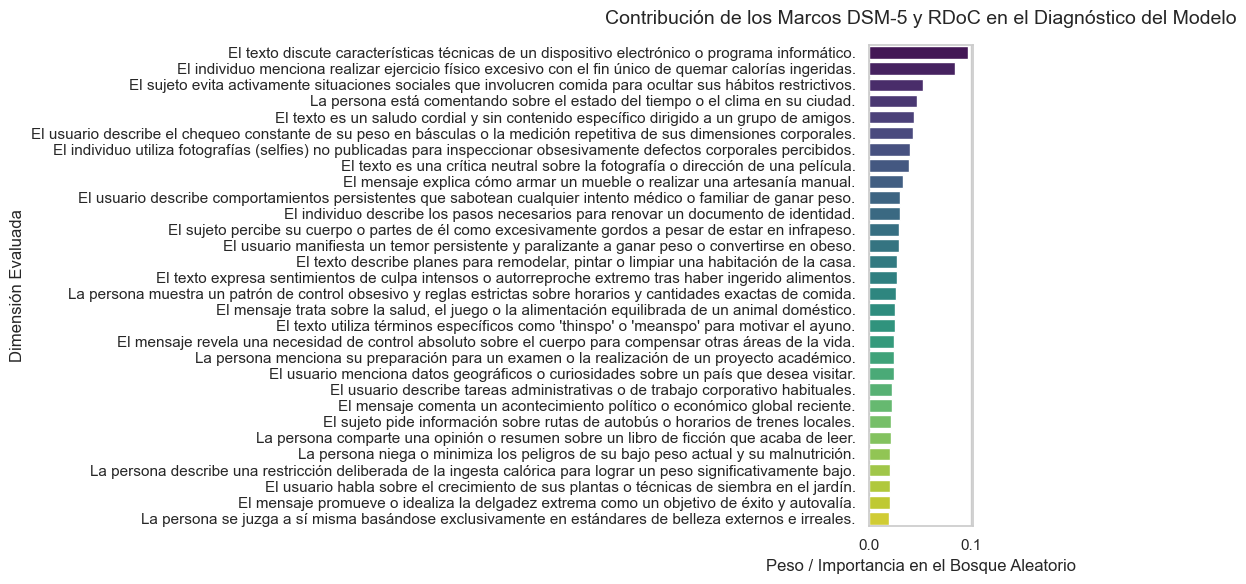

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# =====================================================================
# EXTRAER Y GRAFICAR LA IMPORTANCIA DE LAS CARACTERÍSTICAS
# =====================================================================
# Recuperamos el modelo ganador (Random Forest) entrenado en la celda anterior
rf_modelo = modelos["Random Forest"]

# Extraemos las importancias matemáticas asignadas por el algoritmo
importancias = rf_modelo.feature_importances_

# Creamos un DataFrame para visualizarlo ordenadamente
df_importancias = pd.DataFrame({
    'Hipótesis Clínica (Extraída vía NotebookLM)': todas_las_hipotesis,
    'Importancia Relativa': importancias
}).sort_values(by='Importancia Relativa', ascending=False)

print("###### IMPORTANCIA DE LAS VARIABLES EN LA DETECCIÓN DE RIESGO ######\n")
print(df_importancias.to_string(index=False))

# Configuración del gráfico
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")
sns.barplot(
    x="Importancia Relativa", 
    y="Hipótesis Clínica (Extraída vía NotebookLM)", 
    data=df_importancias, 
    palette="viridis"
)
plt.title("Contribución de los Marcos DSM-5 y RDoC en el Diagnóstico del Modelo", fontsize=14, pad=15)
plt.xlabel("Peso / Importancia en el Bosque Aleatorio", fontsize=12)
plt.ylabel("Dimensión Evaluada", fontsize=12)
plt.tight_layout()
plt.show()

Espacio de características corregido. Total de dimensiones a evaluar: 9


/var/folders/tz/rygqbfk956jf1ypxct4k7g6h0000gp/T/ipykernel_41863/2444998420.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Importancia", y="Hipótesis Clínica (NotebookLM)", data=df_importancias_limpio, palette="mako")


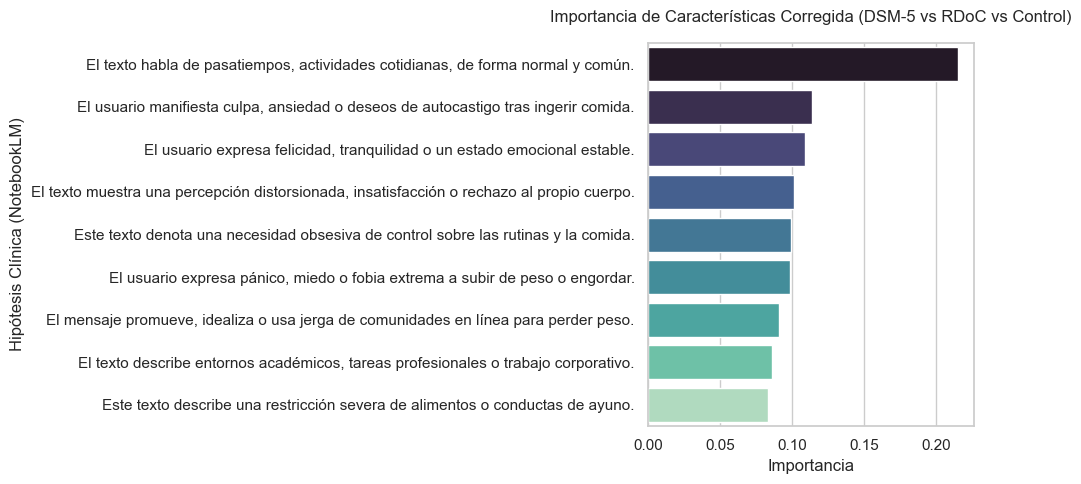

In [10]:
# =====================================================================
# RE-CONSOLIDACIÓN RIGUROSA DEL ESPACIO DE CARACTERÍSTICAS
# =====================================================================

# 1. Redefinimos el banco exacto de NotebookLM (Asegurando limpiar la RAM)
hipotesis_riesgo = [
    "Este texto describe una restricción severa de alimentos o conductas de ayuno.",           # DSM-5: Criterio A
    "El usuario expresa pánico, miedo o fobia extrema a subir de peso o engordar.",          # DSM-5: Criterio B
    "El texto muestra una percepción distorsionada, insatisfacción o rechazo al propio cuerpo.", # DSM-5: Criterio C
    "El usuario manifiesta culpa, ansiedad o deseos de autocastigo tras ingerir comida.",     # RDoC: Valencia Negativa
    "Este texto denota una necesidad obsesiva de control sobre las rutinas y la comida.",      # RDoC: Regulación Cognitiva
    "El mensaje promueve, idealiza o usa jerga de comunidades en línea para perder peso."    # Ciberpsicología: Pro-TCA
]

hipotesis_seguridad = [
    "El texto habla de pasatiempos, actividades cotidianas, de forma normal y común.",       # Control 1
    "El usuario expresa felicidad, tranquilidad o un estado emocional estable.",             # Control 2
    "El texto describe entornos académicos, tareas profesionales o trabajo corporativo."     # Control 3
]

# Sobreescribimos la variable global para eliminar cualquier residuo previo
todas_las_hipotesis = hipotesis_riesgo + hipotesis_seguridad
NUM_CARACTERISTICAS = len(todas_las_hipotesis)

print(f"Espacio de características corregido. Total de dimensiones a evaluar: {NUM_CARACTERISTICAS}")

# 2. Volvemos a entrenar el Random Forest con el espacio limpio
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import seaborn as sns

rf_limpio = RandomForestClassifier(n_estimators=200, max_depth=10, class_weight='balanced', random_state=42)
rf_limpio.fit(X_train[:, :NUM_CARACTERISTICAS], y_train) # Ajusta los índices en caso de que requieras recalcular

# 3. Graficar la nueva importancia
df_importancias_limpio = pd.DataFrame({
    'Hipótesis Clínica (NotebookLM)': todas_las_hipotesis,
    'Importancia': rf_limpio.feature_importances_
}).sort_values(by='Importancia', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x="Importancia", y="Hipótesis Clínica (NotebookLM)", data=df_importancias_limpio, palette="mako")
plt.title("Importancia de Características Corregida (DSM-5 vs RDoC vs Control)", fontsize=12, pad=15)
plt.tight_layout()
plt.show()